# TRANSFORMACIÓN DE DATOS

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [2]:
cat = pd.read_pickle('../02_datos/03_Entrenamiento/cat_eda.pkl')
num = pd.read_pickle('../02_datos/03_Entrenamiento/num_eda.pkl')

Recordamos lo que habíamos identificado en fases anteriores y lo organizamos por tipo de acción.

Modificar con pandas/numpy:

* Crear la target a partir de estado
* Discretizar num_meses_desde_ult_retraso
* En vivienda juntar ANY, NONE y OTHER
* En finalidad juntar renewable_energy, educational y wedding en 'otros'

Modificar con scikit learn:

* Convertir num_derogatorios a binaria

## CREACIÓN DE VARIABLES Y TRANSFORMACIONES CON PANDAS

### Target para el modelo PD  (PROBABILITY OF DEFAULT)

Crear la target a partir de estado

Notas: 

charged off. El banco te da por perdido.
in Grace Period. es un plazo corto extra donde no hay penalizaciones ni intereses. No es malo.

In [3]:
cat.estado.value_counts()

estado
Fully Paid                                             66497
Current                                                54384
Charged Off                                            16399
Late (31-120 days)                                      1332
In Grace Period                                          533
Late (16-30 days)                                        297
Does not meet the credit policy. Status:Fully Paid       111
Does not meet the credit policy. Status:Charged Off       52
Default                                                    3
Name: count, dtype: int64

In [4]:
cat['target_pd'] = np.where(cat.estado.isin(['Charged Off','Does not meet the credit policy. Status:Charged Off','Default']), 1, 0)
cat

,antigüedad_empleo,ingresos_verificados,rating,vivienda,finalidad,num_cuotas,estado,target_pd
0,5 years,Verified,A,RENT,debt_consolidation,36 months,Fully Paid,0
1,7 years,Source Verified,B,MORTGAGE,debt_consolidation,36 months,Fully Paid,0
2,10+ years,Source Verified,D,MORTGAGE,home_improvement,60 months,Current,0
3,3 years,Not Verified,A,RENT,debt_consolidation,36 months,Current,0
4,10+ years,Verified,C,MORTGAGE,credit_card,36 months,Fully Paid,0
...,...,...,...,...,...,...,...,...
139995,4 years,Source Verified,B,RENT,credit_card,36 months,Fully Paid,0
139996,4 years,Verified,B,RENT,debt_consolidation,60 months,Fully Paid,0
139997,6 years,Verified,B,MORTGAGE,other,36 months,Current,0
139998,10+ years,Source Verified,D,MORTGAGE,small_business,36 months,Current,0


In [5]:
cat.drop(columns='estado',inplace=True)

In [6]:
cat.target_pd.value_counts(normalize=True)

target_pd
0   0.882
1   0.118
Name: proportion, dtype: float64

### Target para el modelo EAD (EXPOSURE AT DEFAULT)

Será el porcentaje del principal que no había sido amortizado (por las buenas)

Por tanto: pendiente / principal

Primero tenemos que construir el pendiente como el principal menos el amortizado.

In [7]:
num['pendiente'] = num.principal - num.imp_amortizado
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente
0,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000
1,132883631,125000.000,9.000,1,6,33.300,69.900,0,0,16,22000.000,10.900,719.220,22000.000,0.000,9.000,0.000
2,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730
3,143175635,73000.000,5.520,0,6,0.000,14.900,0,0,0,7200.000,7.210,223.010,725.510,0.000,5.520,6474.490
4,44795538,98000.000,20.490,3,21,40.000,60.000,0,0,56,21000.000,13.990,717.630,21000.000,0.000,20.490,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,40000.000,23.310,0,7,75.000,88.000,0,0,0,15000.000,11.530,494.860,15000.000,0.000,23.310,0.000
139996,999338,55000.000,29.260,0,7,0.000,66.400,0,0,0,20000.000,12.690,451.900,20000.000,0.000,29.260,0.000
139997,121031962,111697.000,16.630,2,10,50.000,26.300,0,1,6,10000.000,9.440,320.050,4388.510,0.000,16.630,5611.490
139998,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470


In [8]:
num['target_ead'] = num.pendiente / num.principal
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead
0,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000
1,132883631,125000.000,9.000,1,6,33.300,69.900,0,0,16,22000.000,10.900,719.220,22000.000,0.000,9.000,0.000,0.000
2,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888
3,143175635,73000.000,5.520,0,6,0.000,14.900,0,0,0,7200.000,7.210,223.010,725.510,0.000,5.520,6474.490,0.899
4,44795538,98000.000,20.490,3,21,40.000,60.000,0,0,56,21000.000,13.990,717.630,21000.000,0.000,20.490,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,40000.000,23.310,0,7,75.000,88.000,0,0,0,15000.000,11.530,494.860,15000.000,0.000,23.310,0.000,0.000
139996,999338,55000.000,29.260,0,7,0.000,66.400,0,0,0,20000.000,12.690,451.900,20000.000,0.000,29.260,0.000,0.000
139997,121031962,111697.000,16.630,2,10,50.000,26.300,0,1,6,10000.000,9.440,320.050,4388.510,0.000,16.630,5611.490,0.561
139998,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820


In [9]:
num.target_ead.describe()

count   139608.000
mean         0.337
std          0.369
min         -0.000
25%          0.000
50%          0.129
75%          0.725
max          1.000
Name: target_ead, dtype: float64

### Target para el modelo LGD (LOSS GIVEN DEFAULT)

Será el porcentaje del pendiente que NO se recupera en caso de impago.

Por tanto: 1 - (imp_recuperado / pendiente)

In [10]:
num['target_lgd'] = 1 - (num.imp_recuperado / num.pendiente)
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead,target_lgd
0,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000,NaN
1,132883631,125000.000,9.000,1,6,33.300,69.900,0,0,16,22000.000,10.900,719.220,22000.000,0.000,9.000,0.000,0.000,NaN
2,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888,1.000
3,143175635,73000.000,5.520,0,6,0.000,14.900,0,0,0,7200.000,7.210,223.010,725.510,0.000,5.520,6474.490,0.899,1.000
4,44795538,98000.000,20.490,3,21,40.000,60.000,0,0,56,21000.000,13.990,717.630,21000.000,0.000,20.490,0.000,0.000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,40000.000,23.310,0,7,75.000,88.000,0,0,0,15000.000,11.530,494.860,15000.000,0.000,23.310,0.000,0.000,NaN
139996,999338,55000.000,29.260,0,7,0.000,66.400,0,0,0,20000.000,12.690,451.900,20000.000,0.000,29.260,0.000,0.000,NaN
139997,121031962,111697.000,16.630,2,10,50.000,26.300,0,1,6,10000.000,9.440,320.050,4388.510,0.000,16.630,5611.490,0.561,1.000
139998,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820,1.000


Los nulos se producen cuando el pendiente es cero. Por tanto podemos imputarlos por ceros.

In [11]:
num['target_lgd'] = num['target_lgd'].fillna(0)
num

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado,DTI,pendiente,target_ead,target_lgd
0,46641215,135000.000,14.680,0,19,0.000,16.300,0,0,0,24000.000,6.390,734.380,24000.000,0.000,14.680,0.000,0.000,0.000
1,132883631,125000.000,9.000,1,6,33.300,69.900,0,0,16,22000.000,10.900,719.220,22000.000,0.000,9.000,0.000,0.000,0.000
2,131289518,72777.000,24.740,2,10,33.300,63.200,0,0,0,25000.000,21.850,688.350,2811.270,0.000,24.740,22188.730,0.888,1.000
3,143175635,73000.000,5.520,0,6,0.000,14.900,0,0,0,7200.000,7.210,223.010,725.510,0.000,5.520,6474.490,0.899,1.000
4,44795538,98000.000,20.490,3,21,40.000,60.000,0,0,56,21000.000,13.990,717.630,21000.000,0.000,20.490,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,40000.000,23.310,0,7,75.000,88.000,0,0,0,15000.000,11.530,494.860,15000.000,0.000,23.310,0.000,0.000,0.000
139996,999338,55000.000,29.260,0,7,0.000,66.400,0,0,0,20000.000,12.690,451.900,20000.000,0.000,29.260,0.000,0.000,0.000
139997,121031962,111697.000,16.630,2,10,50.000,26.300,0,1,6,10000.000,9.440,320.050,4388.510,0.000,16.630,5611.490,0.561,1.000
139998,135641397,285000.000,6.020,3,9,25.000,21.100,0,0,25,30000.000,17.470,1076.620,5387.530,0.000,6.020,24612.470,0.820,1.000


Comprobamos las targets creadas.

In [12]:
cat[['target_pd']].describe()

,target_pd
count,139608.000
mean,0.118
std,0.322
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,1.000


In [13]:
num[['target_ead','target_lgd']].describe().T

,count,mean,std,min,25%,50%,75%,max
target_ead,139608.000,0.337,0.369,-0.000,0.000,0.129,0.725,1.000
target_lgd,139608.000,0.509,0.490,-0.248,0.000,0.850,1.000,1.000


Limitamos para garantizar que siempre estén entre 0 y 1

In [14]:
num.target_ead = np.where(num.target_ead < 0, 0, num.target_ead)
num.target_ead = np.where(num.target_ead > 1, 1, num.target_ead)
num.target_lgd = np.where(num.target_lgd < 0, 0, num.target_lgd)
num.target_lgd = np.where(num.target_lgd > 1, 1, num.target_lgd)

In [15]:
num[['target_ead','target_lgd']].describe().T

,count,mean,std,min,25%,50%,75%,max
target_ead,139608.000,0.337,0.369,0.000,0.000,0.129,0.725,1.000
target_lgd,139608.000,0.509,0.490,0.000,0.000,0.850,1.000,1.000


### Resto de variables

num_meses_desde_ult_retraso

Vamos a comenzar revisando la relación con la target_pd

In [16]:
temp = num[['num_meses_desde_ult_retraso']].copy()

In [17]:
temp['num_meses_desde_ult_retraso_tramos'] = pd.cut(temp['num_meses_desde_ult_retraso'],20)
temp['target'] = cat['target_pd']

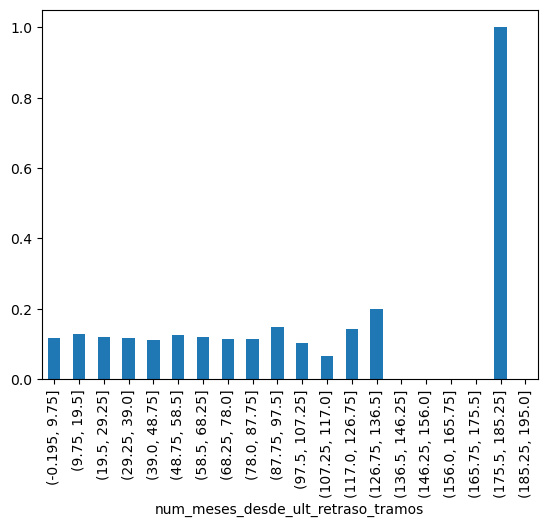

In [18]:
temp.groupby('num_meses_desde_ult_retraso_tramos', observed=False).target.mean().plot.bar();

La distribución de la target en esta variable no nos genera confianza, así que la descartamos.

NOTA MÍA. No estoy muy de acuerdo. Para muy elevados meses, sí que hay un pico en la target

In [19]:
# decido NO DROPEARLA
num.drop(columns='num_meses_desde_ult_retraso',inplace=True)

En vivienda juntar ANY, NONE y OTHER

In [20]:
cat.vivienda.value_counts()

vivienda
MORTGAGE    68452
RENT        55453
OWN         15636
ANY            56
OTHER          10
NONE            1
Name: count, dtype: int64

In [21]:
# decido yo juntar ANY y NONE con OTHER. lo veo más correcto que decir que tienen hipoteca
cat.vivienda = cat.vivienda.replace(['ANY','NONE','OTHER'],'MORTGAGE')

In [22]:
cat.vivienda.value_counts()

vivienda
MORTGAGE    68519
RENT        55453
OWN         15636
Name: count, dtype: int64

En finalidad juntar renewable_energy, educational y wedding en 'otros'

In [23]:
cat.finalidad.value_counts()

finalidad
debt_consolidation    79253
credit_card           31708
home_improvement       9063
other                  8576
major_purchase         3144
medical                1687
small_business         1585
car                    1442
vacation               1015
moving                 1003
house                   897
wedding                 139
renewable_energy         70
educational              26
Name: count, dtype: int64

In [24]:
cat.finalidad = cat.finalidad.replace(['wedding','educational','renewable_energy'],'other')

In [25]:
cat.finalidad.value_counts()

finalidad
debt_consolidation    79253
credit_card           31708
home_improvement       9063
other                  8811
major_purchase         3144
medical                1687
small_business         1585
car                    1442
vacation               1015
moving                 1003
house                   897
Name: count, dtype: int64

## TRANSFORMACIÓN DE CATEGÓRICAS

### One Hot Encoding

#### Variables a aplicar OHE

In [26]:
var_ohe = [ 'ingresos_verificados', 'vivienda','finalidad','num_cuotas']

#### Instanciar

In [27]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output = False, handle_unknown='ignore')

#### Entrenar y aplicar

In [28]:
cat_ohe = ohe.fit_transform(cat[var_ohe])

#### Guardar como dataframe

In [29]:
cat_ohe = pd.DataFrame(cat_ohe, columns = ohe.get_feature_names_out())
cat_ohe.head()

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,finalidad_house,finalidad_major_purchase,finalidad_medical,finalidad_moving,finalidad_other,finalidad_small_business,finalidad_vacation,num_cuotas_ 36 months,num_cuotas_ 60 months
0,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
1,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
2,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
3,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
4,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000


### Ordinal Encoding

#### Variables a aplicar OE

In [30]:
var_oe = ['antigüedad_empleo','rating']

#### Orden de los valores de las variables

In [31]:
#Orden de la primera variable
orden_antigüedad_empleo = ['desconocido','< 1 year','1 year','2 years','3 years','4 years',
                           '5 years','6 years','7 years','8 years','9 years','10+ years']

#Orden de la segunda variable
orden_rating = ['A','B','C','D','E','F','G']

#### Instanciar

In [32]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories = [orden_antigüedad_empleo,orden_rating],
                    handle_unknown = 'use_encoded_value',
                    unknown_value = 12)

#### Entrenar y aplicar

In [33]:
cat_oe = oe.fit_transform(cat[var_oe])

#### Guardar como dataframe

In [34]:
#Añadir sufijos a los nombres
nombres_oe = [variable + '_oe' for variable in var_oe]

#Guardar como dataframe
cat_oe = pd.DataFrame(cat_oe, columns = nombres_oe)
cat_oe.head()

,antigüedad_empleo_oe,rating_oe
0,6.000,0.000
1,8.000,1.000
2,11.000,3.000
3,4.000,0.000
4,11.000,2.000


## TRANSFORMACIÓN DE NUMÉRICAS

### Binarizar variables

#### Variables a binarizar

In [35]:
var_bin = ['num_derogatorios']

#### Instanciar

In [36]:
from sklearn.preprocessing import Binarizer
bin = Binarizer(threshold=0)

#### Entrenar y aplicar

In [37]:
num_bin = bin.fit_transform(num[var_bin])

#### Guardar como dataframe

In [38]:
#Añadir sufijos a los nombres
nombres_bin = [variable + '_bin' for variable in var_bin]

#Guardar como dataframe
num_bin = pd.DataFrame(num_bin,columns = nombres_bin)
num_bin.value_counts()

num_derogatorios_bin
0                       117337
1                        22271
Name: count, dtype: int64

## REESCALAR VARIABLES

### Con Min-Max

Unificar los datasets a reescalar.

In [39]:
num_escalar = num[['ingresos',
                  'dti',
                  'num_lineas_credito',
                  'porc_uso_revolving',
                #'num_meses_desde_ult_retraso', #yo he metido esta variable
                  'principal',
                  'tipo_interes',
                  'imp_cuota']].reset_index(drop=True)

In [40]:
df_res = pd.concat([cat_oe,num_escalar], axis=1)

In [41]:
df_res

,antigüedad_empleo_oe,rating_oe,ingresos,dti,num_lineas_credito,porc_uso_revolving,principal,tipo_interes,imp_cuota
0,6.000,0.000,135000.000,14.680,19,16.300,24000.000,6.390,734.380
1,8.000,1.000,125000.000,9.000,6,69.900,22000.000,10.900,719.220
2,11.000,3.000,72777.000,24.740,10,63.200,25000.000,21.850,688.350
3,4.000,0.000,73000.000,5.520,6,14.900,7200.000,7.210,223.010
4,11.000,2.000,98000.000,20.490,21,60.000,21000.000,13.990,717.630
...,...,...,...,...,...,...,...,...,...
139603,5.000,1.000,40000.000,23.310,7,88.000,15000.000,11.530,494.860
139604,5.000,1.000,55000.000,29.260,7,66.400,20000.000,12.690,451.900
139605,7.000,1.000,111697.000,16.630,10,26.300,10000.000,9.440,320.050
139606,11.000,3.000,285000.000,6.020,9,21.100,30000.000,17.470,1076.620


#### Variables a reescalar con Min-Max

In [42]:
var_mms = df_res.columns

#### Instanciar

In [43]:
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

#### Entrenar y aplicar

In [44]:
df_mms = mms.fit_transform(df_res[var_mms])

#### Guardar como dataframe

In [45]:
#Añadir sufijos a los nombres
nombres_mms = [variable + '_mms' for variable in var_mms]

#Guardar como dataframe
df_mms = pd.DataFrame(df_mms,columns = nombres_mms)
df_mms.describe().T

,count,mean,std,min,25%,50%,75%,max
antigüedad_empleo_oe_mms,139608.000,0.589,0.362,0.000,0.273,0.545,1.000,1.000
rating_oe_mms,139608.000,0.278,0.210,0.000,0.167,0.333,0.333,1.000
ingresos_mms,139608.000,0.190,0.114,0.000,0.115,0.163,0.233,1.000
dti_mms,139608.000,0.019,0.014,0.000,0.012,0.018,0.024,1.000
num_lineas_credito_mms,139608.000,0.138,0.067,0.000,0.095,0.131,0.167,1.000
porc_uso_revolving_mms,139608.000,0.503,0.247,0.000,0.316,0.503,0.693,1.000
principal_mms,139608.000,0.368,0.232,0.000,0.190,0.311,0.494,1.000
tipo_interes_mms,139608.000,0.303,0.188,0.000,0.163,0.285,0.416,1.000
imp_cuota_mms,139608.000,0.253,0.157,0.000,0.139,0.213,0.339,1.000


## UNIFICAR DATASETS

### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de PD

In [46]:
incluir_pd = [num[['id_cliente']].reset_index(drop=True), cat_ohe, df_mms, num_bin, cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de PD

In [47]:
df_pd = pd.concat(incluir_pd, axis = 1)

In [48]:
df_pd

,id_cliente,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_pd
0,46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.000,0.338,0.015,0.226,0.163,0.595,0.042,0.423,0,0
1,132883631,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,...,0.167,0.312,0.009,0.071,0.699,0.544,0.218,0.414,0,0
2,131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.182,0.025,0.119,0.632,0.620,0.644,0.396,0,0
3,143175635,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.000,0.183,0.006,0.071,0.149,0.170,0.074,0.122,0,0
4,44795538,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,...,0.333,0.245,0.021,0.250,0.600,0.519,0.338,0.413,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139603,51896222,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,...,0.167,0.100,0.023,0.083,0.880,0.367,0.242,0.282,0,0
139604,999338,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,...,0.167,0.138,0.029,0.083,0.664,0.494,0.287,0.257,0,0
139605,121031962,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.167,0.279,0.017,0.119,0.263,0.241,0.161,0.179,1,0
139606,135641397,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.713,0.006,0.107,0.211,0.747,0.474,0.624,0,0


In [49]:
df_pd.set_index('id_cliente',inplace=True)
df_pd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.000,0.338,0.015,0.226,0.163,0.595,0.042,0.423,0,0
132883631,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.167,0.312,0.009,0.071,0.699,0.544,0.218,0.414,0,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.500,0.182,0.025,0.119,0.632,0.620,0.644,0.396,0,0
143175635,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.000,0.183,0.006,0.071,0.149,0.170,0.074,0.122,0,0
44795538,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.333,0.245,0.021,0.250,0.600,0.519,0.338,0.413,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51896222,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,...,0.167,0.100,0.023,0.083,0.880,0.367,0.242,0.282,0,0
999338,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.138,0.029,0.083,0.664,0.494,0.287,0.257,0,0
121031962,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.167,0.279,0.017,0.119,0.263,0.241,0.161,0.179,1,0


### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de EAD

Notar que necesitamos incluir también target_pd porque para modelizar ead debemos hacerlo solo sobre los defaults.

A diferencia del PD en los modelos EAD y LGD solo se usan los defaults para modelizar.

El motivo es que LGD y EAD modelan la severidad del default una vez ocurre. Si el default no ocurre, no hay severidad que observar.

In [50]:
incluir_ead = [cat_ohe, df_mms, num_bin, num.reset_index()[['id_cliente','target_ead']], cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de EAD

In [51]:
df_ead = pd.concat(incluir_ead, axis = 1)

In [52]:
df_ead.set_index('id_cliente',inplace=True)
df_ead

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_ead,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.338,0.015,0.226,0.163,0.595,0.042,0.423,0,0.000,0
132883631,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.312,0.009,0.071,0.699,0.544,0.218,0.414,0,0.000,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.182,0.025,0.119,0.632,0.620,0.644,0.396,0,0.888,0
143175635,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.183,0.006,0.071,0.149,0.170,0.074,0.122,0,0.899,0
44795538,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.245,0.021,0.250,0.600,0.519,0.338,0.413,0,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51896222,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,...,0.100,0.023,0.083,0.880,0.367,0.242,0.282,0,0.000,0
999338,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.138,0.029,0.083,0.664,0.494,0.287,0.257,0,0.000,0
121031962,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.279,0.017,0.119,0.263,0.241,0.161,0.179,1,0.561,0


In [53]:
# filtrar solo los clientes que incumplieron y eliminar la variable target_pd
df_ead = df_ead[df_ead.target_pd == 1].drop(columns='target_pd')
df_ead

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_ead
id_cliente,,,,,,,,,,,,,,,,,,,,,
1455880,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.333,0.125,0.010,0.048,0.538,0.089,0.428,0.074,0,0.449
79731947,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.208,0.028,0.143,0.826,0.368,0.504,0.312,0,0.979
88146689,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.095,0.008,0.250,0.555,0.190,0.533,0.163,0,0.570
98927973,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.500,0.150,0.013,0.131,0.099,0.595,0.494,0.501,1,0.647
66456046,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.100,0.011,0.226,0.712,0.241,0.230,0.184,0,0.729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94254124,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.333,0.275,0.019,0.167,0.542,0.620,0.416,0.348,0,0.883
13677274,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.333,0.113,0.027,0.119,0.382,0.149,0.345,0.120,0,0.229
93652544,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.167,0.160,0.025,0.131,0.480,0.489,0.241,0.375,1,0.756


### Crear una lista con los dataframes y variables a incluir en el tablón analítico para el modelo de LGD

Notar que necesitamos incluir también target_pd porque para modelizar lgd debemos hacerlo solo sobre los defaults.

In [54]:
incluir_lgd = [cat_ohe, df_mms, num_bin, num.reset_index()[['id_cliente','target_lgd']], cat.reset_index()[['target_pd']]]

### Unir todos los dataframes en el tablón analítico para el modelo de LGD

In [55]:
df_lgd = pd.concat(incluir_lgd, axis = 1)

In [56]:
df_lgd.set_index('id_cliente',inplace=True)
df_lgd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_lgd,target_pd
id_cliente,,,,,,,,,,,,,,,,,,,,,
46641215,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.338,0.015,0.226,0.163,0.595,0.042,0.423,0,0.000,0
132883631,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.312,0.009,0.071,0.699,0.544,0.218,0.414,0,0.000,0
131289518,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.182,0.025,0.119,0.632,0.620,0.644,0.396,0,1.000,0
143175635,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.183,0.006,0.071,0.149,0.170,0.074,0.122,0,1.000,0
44795538,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.245,0.021,0.250,0.600,0.519,0.338,0.413,0,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51896222,0.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,...,0.100,0.023,0.083,0.880,0.367,0.242,0.282,0,0.000,0
999338,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.138,0.029,0.083,0.664,0.494,0.287,0.257,0,0.000,0
121031962,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.279,0.017,0.119,0.263,0.241,0.161,0.179,1,1.000,0


In [57]:
# filtrar solo los clientes que incumplieron y eliminar la variable target_pd
df_lgd = df_lgd[df_lgd.target_pd == 1].drop(columns='target_pd')
df_lgd

,ingresos_verificados_Not Verified,ingresos_verificados_Source Verified,ingresos_verificados_Verified,vivienda_MORTGAGE,vivienda_OWN,vivienda_RENT,finalidad_car,finalidad_credit_card,finalidad_debt_consolidation,finalidad_home_improvement,...,rating_oe_mms,ingresos_mms,dti_mms,num_lineas_credito_mms,porc_uso_revolving_mms,principal_mms,tipo_interes_mms,imp_cuota_mms,num_derogatorios_bin,target_lgd
id_cliente,,,,,,,,,,,,,,,,,,,,,
1455880,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.333,0.125,0.010,0.048,0.538,0.089,0.428,0.074,0,0.754
79731947,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.500,0.208,0.028,0.143,0.826,0.368,0.504,0.312,0,0.900
88146689,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.500,0.095,0.008,0.250,0.555,0.190,0.533,0.163,0,1.000
98927973,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.500,0.150,0.013,0.131,0.099,0.595,0.494,0.501,1,0.862
66456046,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.167,0.100,0.011,0.226,0.712,0.241,0.230,0.184,0,0.897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94254124,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,...,0.333,0.275,0.019,0.167,0.542,0.620,0.416,0.348,0,0.929
13677274,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,...,0.333,0.113,0.027,0.119,0.382,0.149,0.345,0.120,0,0.775
93652544,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.167,0.160,0.025,0.131,0.480,0.489,0.241,0.375,1,1.000


## GUARDAR DATASETS TRAS TRANSFORMACIÓN DE DATOS

In [58]:
# Guardar los archivos
df_pd.to_pickle('../02_datos/03_Entrenamiento/df_tablon_pd.pkl')
df_ead.to_pickle('../02_datos/03_Entrenamiento/df_tablon_ead.pkl')
df_lgd.to_pickle('../02_datos/03_Entrenamiento/df_tablon_lgd.pkl')